Columns:
 Index(['Amount', 'Time', 'Feature1', 'Feature2', 'Fraud'], dtype='object')

Detected Target Column: Fraud

Class Distribution BEFORE SMOTE:
 Fraud
0    110
1     10
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Before SMOTE:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24


Class Distribution AFTER SMOTE:
 Fraud
1    88
0    88
Name: count, dtype: int64

After SMOTE:
               precision    recall  f1-score   support

           0       0.90      0.82      0.86        22
           1       0.00      0.00      0.00         2

    accuracy                           0.75        24
   macro avg       0.45      0.41      0.43        24
weighted avg       0.83      0.75      0.79        24



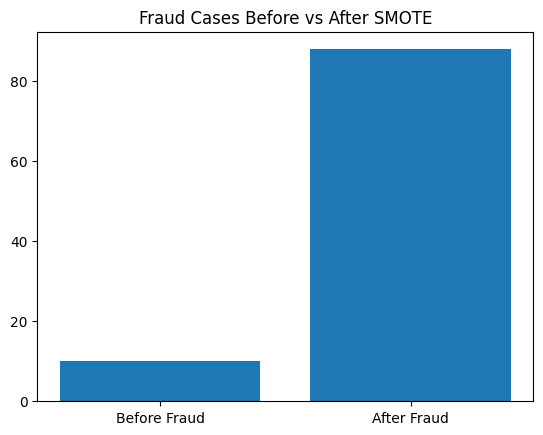

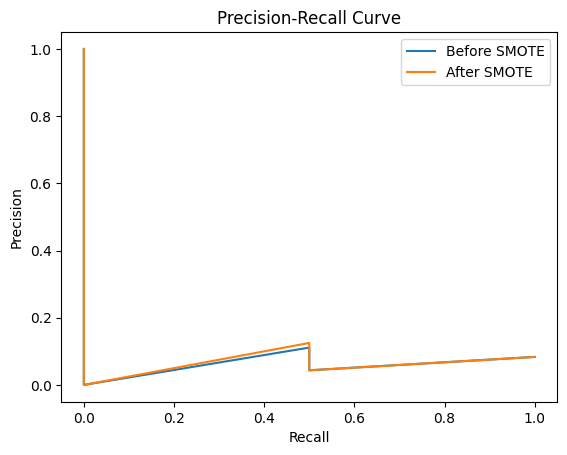

In [3]:
# Name: Navithanjali
# Roll No: 24BAD077
# Scenario 5 - SMOTE (FINAL FIX)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_curve
from imblearn.over_sampling import SMOTE

# ------------------ Load Dataset ------------------
data = pd.read_csv("fraud_smote.csv")

# Clean column names
data.columns = data.columns.str.strip()

print("Columns:\n", data.columns)
target_col = None
for col in data.columns:
    if col.lower() in ['class', 'fraud', 'isfraud', 'target']:
        target_col = col
        break

print("\nDetected Target Column:", target_col)

X = data.drop(target_col, axis=1)
y = data[target_col]

print("\nClass Distribution BEFORE SMOTE:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred_before = model.predict(X_test)
y_prob_before = model.predict_proba(X_test)[:, 1]

print("\nBefore SMOTE:\n", classification_report(y_test, y_pred_before))

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("\nClass Distribution AFTER SMOTE:\n", pd.Series(y_res).value_counts())

model.fit(X_res, y_res)

y_pred_after = model.predict(X_test)
y_prob_after = model.predict_proba(X_test)[:, 1]

print("\nAfter SMOTE:\n", classification_report(y_test, y_pred_after))

# ------------------ Visualization ------------------

# Class distribution graph
plt.bar(["Before Fraud", "After Fraud"],
        [y.value_counts().min(), pd.Series(y_res).value_counts().min()])
plt.title("Fraud Cases Before vs After SMOTE")
plt.show()

# ------------------ Precision-Recall Curve ------------------
precision_before, recall_before, _ = precision_recall_curve(y_test, y_prob_before)
precision_after, recall_after, _ = precision_recall_curve(y_test, y_prob_after)

plt.plot(recall_before, precision_before, label="Before SMOTE")
plt.plot(recall_after, precision_after, label="After SMOTE")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()